In our recent works ([Yokoyama & Kitajo, Commun Eng, 2023](https://doi.org/10.1038/s44172-023-00143-7); [Yokoyama et al, bioRxiv, 2025](https://doi.org/10.1101/2025.03.22.644706)), we propose a method to estimate E/I balance changes by applying neural-mass model-based tracking of the brain state using the variational Bayesian noise adaptive Ensemble transform Kalman filter with state estimation constraint (vbcETKF). <br>
This text explains how to use our implemented algorithm of EEG data assimilation (EEG-DA) through reproducing the numerical simulation results in our papers  ([Yokoyama & Kitajo, Commun Eng, 2023](https://doi.org/10.1038/s44172-023-00143-7); [Yokoyama et al, bioRxiv, 2025](https://doi.org/10.1101/2025.03.22.644706)). 

# _**Short summary of our proposed EEG-DA method**_
 
Before starting to explain our implementations, I will give a short description of the theoretical background of our proposed method. 

In our implemented algorithm, by using vbcETKF, the observation of the single channel EEG is directly assimilated into the neural mass model (NMM) to estimate the internal state of the brain associated with the balance of the synaptic interactions between excitatory and inhibitory neurons (i.e., E/I balance). The NMM is formulated as the following six first-order differential equations.<br>
\begin{equation}
    \begin{split}
    \dot{v}_0 (t) &= v_3 (t) \\
    \dot{v}_1 (t) &= v_4 (t) \\
    \dot{v}_2 (t) &= v_5 (t) \\
    \dot{v}_3 (t) &= A a \mathrm{Sigm}(v_1 (t)-v_2(t)) -2 a v_3(t) - a^2 v_0(t) \\
    \dot{v}_4 (t) &= A a [p(t)+C_2 \mathrm{Sigm}(C_1 v_0(t))]-2av_4 (t)-a^2 v_1(t) \\
    \dot{v}_5 (t) &= B b C_4 \mathrm{Sigm}(C_3 v_0(t)) - 2 b v_5(t) - b^2 v_2(t) \\
    \mathrm{with}&, ~ \mathrm{Sigm}(v) = \dfrac{5.00}{1+\exp\left\{ 0.56 (6.00 - v) \right\}},
    \end{split}
\end{equation}
where variables $v_0$, $v_1$, and $v_2$ indicate the mass of postsynaptic potential (PSP) in three neural populations: pyramidal cells, excitatory interneurons, and inhibitory interneurons, respectively. The synthetic EEGs generated in the NM model are defined as $y(t)= v_1(t)-v_2(t)$. The fixed constants $C_n$  (where $n = 1,...,4$) account for the number of synapses established between two neural populations. $C_n$ was fixed as $C_1=135$, $C_2=108$, $C_3$ and $C_4=33.75$, based on a previous study [(David & Friston, 2003)](https://doi.org/10.1016/j.neuroimage.2003.07.015). The other five parameters in the NM model, $A,~a,~B,~b$, and $p$, are the target-to-state estimation in our EEG-DA method. Parameters $A$ and $B$ represent the excitatory and inhibitory synaptic gains, which control the amplitude of the excitatory PSP (EPSP) and inhibitory PSP (IPSP), respectively. Parameters $a$ and $b$ indicate the inverse of the time constant for EPSP and IPSP that control the dominant frequency band of the generated EEG oscillations in the NM model. Parameter $p$ represents the background noise input of the model. <br>

To apply the NMM to our EEG-DA method, the above differential equations were transformed to the state-space form as follows: 
\begin{equation}
    \dot{\mathbf{v}}_t = 
    \begin{bmatrix}
    \dot{v}_0(t)\\
    \dot{v}_1(t)\\
    \dot{v}_2(t)\\
    \dot{v}_3(t)\\
    \dot{v}_4(t)\\
    \dot{v}_5(t)\\
    \end{bmatrix} =
    \begin{bmatrix}
    v_3(t)\\
    v_4(t)\\
    v_5(t)\\
    A a \mathrm{Sigm}(v_1 (t)-v_2(t)) -2 a v_3(t) - a^2 v_0(t)\\
    A a [p(t)+C_2 \mathrm{Sigm}(C_1 v_0(t))]-2av_4 (t)-a^2 v_1(t)\\
    B b C_4 \mathrm{Sigm}(C_3 v_0(t)) - 2 b v_5(t) - b^2 v_2(t)\\
    \end{bmatrix} = g(\mathbf{v}_t, \mathbf{\theta_t})
\end{equation}

\begin{align}
    \begin{split}
        \mathrm{state~model;} &\\
        x_{t+1} &= 
        \begin{bmatrix}
            \mathbf{v}_t + \int^{t+\Delta t}_{t} g(\mathbf{v}_t, \mathbf{\theta}_t) dt\\
            \mathbf{\theta_t}\\
        \end{bmatrix} + \zeta_t\\ 
        &= f(\mathbf{v}_t, \mathbf{\theta_t}) + \zeta_t\\
        &\;\; \mathrm{where,}\; \;  \zeta_t \sim \mathcal{N}(0, Q)
    \end{split}\\
    \begin{split}
        \mathrm{observation~model;} &\\
        y_{t} &= H x_t + w_t \\
        &= [[0,~1,~-1,~0,~0,~0],~\mathbb{O}^{1\times5}]
        \begin{bmatrix}
            \mathbf{v}_t\\
            \mathbf{\theta_t}\\
        \end{bmatrix} + w_t\\
        &\;\; \mathrm{where,}\; \;  w_t \sim \mathcal{N}(0, \eta_t^{-1}R), \;\; \eta_t \sim \mathcal{G}(\alpha, \beta)
    \end{split}
\end{align}

where $v_t = \{v_0(t),~v_1 (t),~....,~v_5(t)\}$ and $\theta=\{A,a,B,b,p\}$  indicate the model variables and parameters of the NM model, respectively. Note that $\mathbf{v}_t + \int^{t+\Delta t}_{t} g(\mathbf{v}_t, \mathbf{\theta}_t) dt$ was implemented with the Euler method with step size $\Delta t$ (sampling interval). The state $x_t=\{v_t, \theta_t \}^T$ and observation $y_t$ follow Gaussian distributions as $x_t  \sim \mathcal{N}(x_t,P_t ) $ and $y_t  \sim \mathcal{N}(H x_t,~\eta_t^{-1} R)$, respectively. The variable $\xi_t$ is state noise that follows the normal density $\xi_t \sim \mathcal{N}(0,~Q)$. Variable $w_t$ is observation noise, which follows the normal distribution $w_t \sim \mathcal{N}(0,~\eta_t^{-1} R)$. To consider the nonstationary noise effect, we introduced the noise scale factor $\eta_t$ that follows the gamma probability $\eta_t \sim \mathcal{G}(\alpha,~\beta)$. <br>

Applying the above state space form of NNM to vbcETKF, we can estimate both the model state and parameters in NNM based on the observed EEGs. 
In this method, the state $x_t$ and noise scaling factor $\eta_t$ are estimated by solving the following Bayesian theory:
\begin{equation}
    p(x_t,~\eta_t \mid y_{1:t}) \propto p(y_t \mid x_t,~\eta_t) \cdot p(x_t,~\eta_t \mid y_{1:t-1}), 
\end{equation}
where $y_{1:t}$ indicates the observation set as $\{y_1,~y_2,~...,y_t \}$. If $x_t$ and $\eta_t$ can be defined as independent, the posterior distribution $p(x_t,~\eta_t \mid y_{1:t})$ in the above Bayesian theory can be solved by minimizing the Kullback–Leibler (KL) divergence between the approximated distribution $q(x_t) q(\eta_t)$ and exact distribution $p(x_t,~\eta_t \mid y_{1:t})$ [(Sarkka & Nummenmaa. 2009)](https://doi.org/10.1109/TAC.2008.2008348):
\begin{equation}
    \arg\min : D_{KL} [q(x_t)q(\eta_t) \parallel p(x_t,~\eta_t \mid y_{1:t})].
\end{equation}
As a result, the approximated solutions of the above KL divergence could be estimated by our implemented method: vbcETKF. 
For the mathematical details of model estimation procedures with vbcETKF, refer to our recent works ([Yokoyama & Kitajo, Commun Eng, 2023](https://doi.org/10.1038/s44172-023-00143-7); [Yokoyama et al, bioRxiv, 2025](https://doi.org/10.1101/2025.03.22.644706))

# _**Use of Python script for EEG-DA**_
As we mentioned above, we will explain the usage of our Python-implemented codes of the EEG-DA method while reproducing the simulation results in our papers (Yokoyama & Kitajo, [2023](https://doi.org/10.1038/s44172-023-00143-7), [2025](https://doi.org/10.1101/2025.03.22.644706)). The main aim of the following simulations is to validate the reliability of the estimation results obtained from our proposed vbcETKF-based EEG-DA method by confirming whether our method can obtain a consistent result in the estimation for E/I balance changes. 
The following descriptions and sample simulation codes are based on the Python script: "demo_vbETKF_pred.py," which can be found in [my GitHub repository](https://github.com/myGit-YokoyamaHiroshi/EEG_vbcETKF_mEI_est/tree/main/numerical_sim/new_method_vbcETKF). <br>

At first, we set the current directory and configuration for matplotlib modules as below.

In [1]:
from copy import deepcopy, copy
import os
notebook_path = os.path.abspath("D:/OU/Briefcase/Python_Scripts/constrained_vbETKF_NeuralMass")
os.chdir(notebook_path)

param_path   = notebook_path + '/save_data/' 
if os.path.exists(param_path)==False:  # Make the directory for figures
    os.makedirs(param_path)
    
import matplotlib.pylab as plt
from matplotlib import font_manager
import matplotlib

plt.rcParams['font.family']      = 'Arial'
plt.rcParams['mathtext.fontset'] = 'stix' 
plt.rcParams['xtick.direction']  = 'in'
plt.rcParams['ytick.direction']  = 'in'
plt.rcParams["font.size"]        = 22 
plt.rcParams['lines.linewidth']  = 1.0
plt.rcParams['figure.dpi']       = 96
plt.rcParams['savefig.dpi']      = 600 

Next, by conducting the following part, the main module of our EEG-DA algorithm containing "/my_modules/vb_etkf_JRmodel.py" in [my Git-Hub repository](https://github.com/myGit-YokoyamaHiroshi/EEG_vbcETKF_mEI_est/tree/main/numerical_sim/new_method_vbcETKF) would be imported as below.

In [2]:
import sys
sys.path.append(notebook_path)
print(notebook_path)

import numpy as np
import joblib
import multiprocessing as multi

from my_modules.vb_etkf_JRmodel import vbETKF_JansenRit

D:\OU\Briefcase\Python_Scripts\constrained_vbETKF_NeuralMass


For applying our EEG-DA algorithm with parallel loop using the Joblib module, we first define the execution function for the EEG-DA method as below. <br>

In [3]:
def est_model(eeg, time, Nstate, Nt, Npar, dt):
    
    # Set the initial value of the model parameters applying vbcETKF algorithm 
    A          = 3.25 
    a          = 100
    B          = 22
    b          = 50
    p          = 220
    Q          = np.diag(np.hstack((1E-2 * dt * np.ones(6), 1E-3 * np.ones(5))))
    R          = 50
    
    xEst       = np.zeros(Nstate)
    PEst       = np.eye(Nstate)
    xEst[6:]   = np.array([A, a, B, b, p]) 

    # Define the variables to store the estimation results 
    x_pred      = np.zeros((Nt, Nstate))
    eeg_pred    = np.zeros(Nt)
    eeg_observe = eeg 
    x_pred[0,:] = xEst
    ELBO        = np.zeros(Nt)
    R_save      = np.zeros(Nt)
    R_save[0]   = R
    
    ## Initialize EEG-DA module: vbETKF_JansenRit 
    model = vbETKF_JansenRit(xEst, PEst, Q, R, dt, Npar)
    
    for t in range(1,Nt):
        z = eeg_observe[t-1] 
        ### update model
        model.vbetkf_estimation(z)
        
        # store data history
        PEst = model.P
        eta_ = model.b/model.a
        R    =  (eta_) * model.R
        
        x_pred[t,:] = model.X
        eeg_pred[t] = model.zPred[0]
        ELBO[t]     = model.elbo
        R_save[t]   = R
        if np.mod(t+1, 10)==0:
            print('#itr.: %d (R = %5.8f)'%((t+1), R))
        #%%
    param_pred = x_pred[:,6:]
    
    #%%
    return eeg_pred, param_pred, R_save, Npar

As can be seen in the above, the state noise covariance $Q$ is defined as $Q = \mathrm{diag} \left(\left[\Delta t  \cdot Q_v,~ Q_{\theta} \right] \right) = \mathrm{diag} \left(\left[ \Delta t \cdot 10^{-2} \cdot \mathbb{I}^{1\times6},10^{-3} \cdot \mathbb{I}^{1\times5} \right] \right)$. <br>
The $\Delta t \cdot Q_v = \Delta t \cdot 10^{-2} \cdot \mathbb{I}^{1\times6}$ is set to satisfy the following relationship in the NNM:
\begin{equation}
    \begin{split}
        & d\mathbf{v}_t/dt = g(\mathbf{v}_t, \mathbf{\theta}_t) \\
        & \rightarrow \mathbf{v}_{t+1} = \mathbf{v}_{t} + \int^{t+1}_{t} g(\mathbf{v}_t, \mathbf{\theta}_t) dt + \sqrt{dt} \zeta_t \\
        & ~~~ \mathrm{with,} ~~~~ \sqrt{dt} \zeta_t \sim \mathcal{N}(0, dt \cdot Q_v)
    \end{split}
\end{equation}

Other parameter settins are based on our recent papers ([Yokoyama & Kitajo, Commun Eng, 2023](https://doi.org/10.1038/s44172-023-00143-7); [Yokoyama et al, bioRxiv, 2025](https://doi.org/10.1101/2025.03.22.644706)).

After conducting all above process, we then load the dataset of synthetic observational EEGs as shown in the following panel. The original code to generate the dataset of synthetic observational EEGs (file name: "'synthetic_data.npy") can be found in the script "make_synthetic_data_JRmodel.py" containing the [repository](https://github.com/myGit-YokoyamaHiroshi/EEG_vbcETKF_mEI_est/tree/main/numerical_sim/new_method_vbcETKF). 

In [4]:
Ntri        = 50
Npar        = 70
fullpath    = param_path + 'synthetic_data.npy'
param_dict  = np.load(fullpath, encoding='ASCII', allow_pickle='True').item()
eeg         = param_dict['eeg']
t_true      = param_dict['t']
fs          = param_dict['fs']
dt          = param_dict['dt']

x_true      = param_dict['y']     # exact value of satate variables 1 (numerical solution of Neural mass model)
param_true  = param_dict['param'] # exact value of satate variables 2 (parameters of Neural mass model)

noise       = np.random.normal(loc = 0, scale=np.sqrt(1.3), size=len(eeg))

s_power     = np.mean((eeg-eeg.mean())**2)
n_power     = np.mean((noise-noise.mean())**2)
SNR         = np.log10(s_power/n_power)
print('SNR = %.3f (dB)'%SNR)

eeg         = eeg + noise
Nstate      = (x_true.shape[1]) + param_true.shape[1]

Nt          = len(eeg)
dt          = 1/fs
time        = np.arange(0,Nt,1)/fs

SNR = 0.691 (dB)


Finally, by using the above-defined execution function of vbcETKF, we will conduct the numerical simulation of EEG-DA. In this simulation, we aim to confirm the reliability of the estimation results obtained from our vbcETKF-based EEG-DA method, since the estimation results in vbcETKF contains the probabkistic uncertainty caused by the sequential Monte Carlo for Bayesian probability estimation in ETKF scheme. To do so, the synthetic observed EEGs are repetitively applied to our vbcETKF 50 times with a joblib parallel loop based on the different initial values of the random seed. 

In [5]:
np.random.seed(0) # set the initial seed as 0 for reproducibility 

processed  = joblib.Parallel(n_jobs=10, verbose=5)(joblib.delayed(est_model)(eeg, time, Nstate, Nt, Npar, dt) for i in range(Ntri))
#%%
eeg_pred   = np.array([processed[i][0] for i in range(len(processed))])
param_pred = np.array([processed[i][1] for i in range(len(processed))])
R_save     = np.array([processed[i][2] for i in range(len(processed))])

[Parallel(n_jobs=10)]: Using backend LokyBackend with 10 concurrent workers.
[Parallel(n_jobs=10)]: Done  42 out of  50 | elapsed:  1.5min remaining:   16.5s
[Parallel(n_jobs=10)]: Done  50 out of  50 | elapsed:  1.5min finished


Once the above parallel processing is completed, we calculate the exact and estimated values of the model-based E/I balance index (mE/I) based on the exact and estimated excitatory and inhibitory gain parameters $A$ and $B$, which is defined as the following equation:
\begin{equation}
    mEI = \frac{A}{A+B}
\end{equation}

In [6]:
mEI_true  = param_true[:,0]/(param_true[:,0] + param_true[:,2])
mEI_pred  = param_pred[:,:,0]/(param_pred[:,:,0] + param_pred[:,:,2])

All estimation results can be visualized as below.

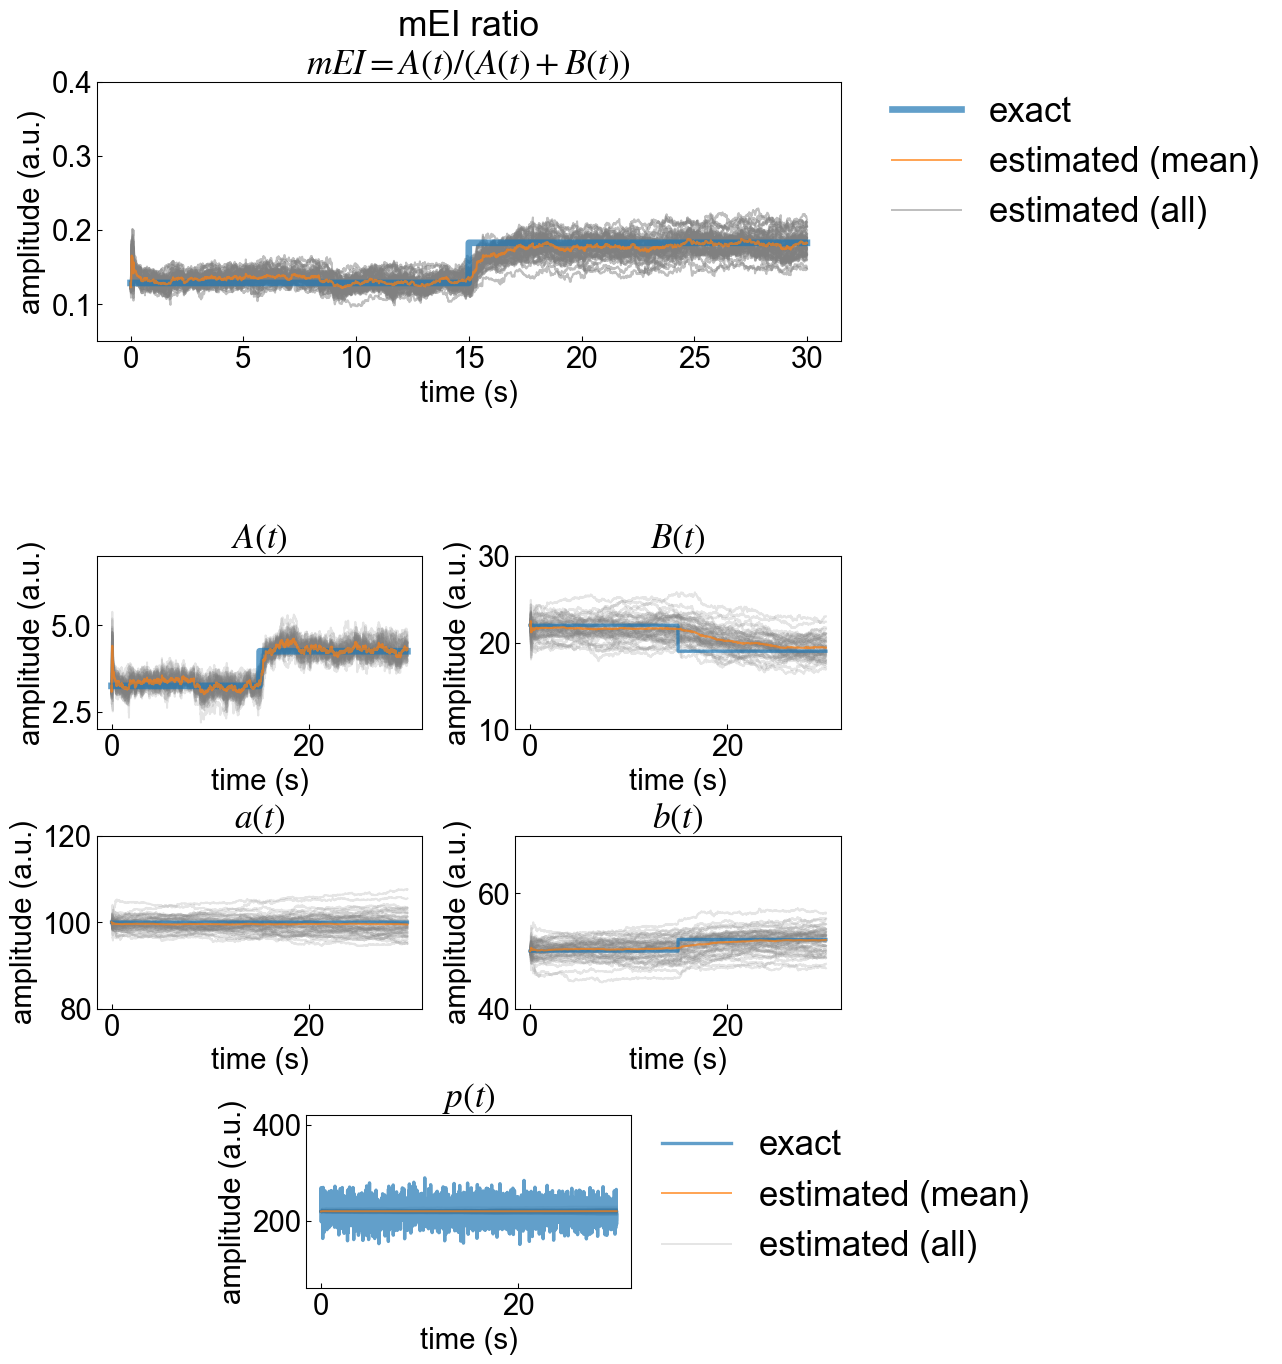

In [7]:
fig = plt.figure(figsize=(10, 18))
gs  = fig.add_gridspec(6,4,height_ratios=[1.5,0.01,1,1,1, 0.1])
plt.subplots_adjust(wspace=0.8, hspace=0.8)

ax = fig.add_subplot(gs[0, 0:])
ax.plot(time, mEI_true, color='#1f77b4', label='exact', zorder=1, alpha=0.7, linewidth=5);
ax.plot(time, mEI_pred.mean(axis=0), color='#ff7f0e', alpha=0.7, label='estimated (mean)', zorder=2, linewidth=1.5);
ax.plot(time, mEI_pred.T, color='gray', alpha=0.5, label='estimated', zorder=0, linewidth=1.5);
ax.set_xlabel('time (s)')
ax.set_ylabel('amplitude (a.u.)')
ax.set_ylim(0.05, 0.4)
ax.legend(['exact', 'estimated (mean)', 'estimated (all)'],bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0, fontsize=26, frameon=False)
ax.set_title('mEI ratio\n$mEI = A(t)/(A(t)+B(t))$')

### parameter A
ax = fig.add_subplot(gs[2, 0:2])
ax.plot(time, param_true[:,0], c='#1f77b4', label='exact', zorder=1, alpha=0.7, linewidth=5);
ax.plot(time, param_pred[:,:,0].mean(axis=0), c='#ff7f0e', alpha=0.7, label='estimated (mean)', zorder=2, linewidth=1.5);
ax.plot(time, param_pred[:,:,0].T, c='gray', alpha=0.2, label='estimated', zorder=0, linewidth=1.5);
ax.set_xlabel('time (s)')
ax.set_ylabel('amplitude (a.u.)')
ax.set_ylim(2, 7)
ax.set_title('$A(t)$')

### parameter B
ax = fig.add_subplot(gs[2, 2:])
ax.plot(time, param_true[:,2], c='#1f77b4', label='exact', zorder=1, alpha=0.7, linewidth=2.5);
ax.plot(time, param_pred[:,:,2].mean(axis=0), c='#ff7f0e', alpha=0.7, label='estimated (mean)', zorder=2, linewidth=1.5);
ax.plot(time, param_pred[:,:,2].T, c='gray', alpha=0.2, label='estimated', zorder=0, linewidth=1.5);
ax.set_xlabel('time (s)')
ax.set_ylabel('amplitude (a.u.)')
ax.set_ylim(10, 30)
ax.set_title('$B(t)$')


### parameter a
ax = fig.add_subplot(gs[3, 0:2])
ax.plot(time, param_true[:,1], c='#1f77b4', label='exact', zorder=1, alpha=0.7, linewidth=2.5);
ax.plot(time, param_pred[:,:,1].mean(axis=0), c='#ff7f0e', alpha=0.7, label='estimated (mean)', zorder=2, linewidth=1.5);
ax.plot(time, param_pred[:,:,1].T, c='gray', alpha=0.2, label='estimated', zorder=0, linewidth=1.5);
ax.set_xlabel('time (s)')
ax.set_ylabel('amplitude (a.u.)')
ax.set_ylim(80, 120)
ax.set_title('$a(t)$')

### parameter b
ax = fig.add_subplot(gs[3, 2:])
ax.plot(time, param_true[:,3], c='#1f77b4', label='exact', zorder=1, alpha=0.7, linewidth=2.5);
ax.plot(time, param_pred[:,:,3].mean(axis=0), c='#ff7f0e', alpha=0.7, label='estimated (mean)', zorder=2, linewidth=1.5);
ax.plot(time, param_pred[:,:,3].T, c='gray', alpha=0.2, label='estimated', zorder=0, linewidth=1.5);
ax.set_xlabel('time (s)')
ax.set_ylabel('amplitude (a.u.)')
ax.set_ylim(40, 70)
ax.set_title('$b(t)$')

### parameter p
ax = fig.add_subplot(gs[4, 1:3])
ax.plot(time, param_true[:,4], c='#1f77b4', label='exact', zorder=1, alpha=0.7, linewidth=2.5);
ax.plot(time, param_pred[:,:,4].mean(axis=0), c='#ff7f0e', alpha=0.7, label='estimated (mean)', zorder=2, linewidth=1.5);
ax.plot(time, param_pred[:,:,4].T, c='gray', alpha=0.2, label='estimated', zorder=0, linewidth=1.5);
ax.set_xlabel('time (s)')
ax.set_ylabel('amplitude (a.u.)')
ax.set_ylim(60, 420)
ax.set_title('$p(t)$')
ax.legend(['exact', 'estimated (mean)', 'estimated (all)'],bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0, fontsize=26, frameon=False)

plt.show()

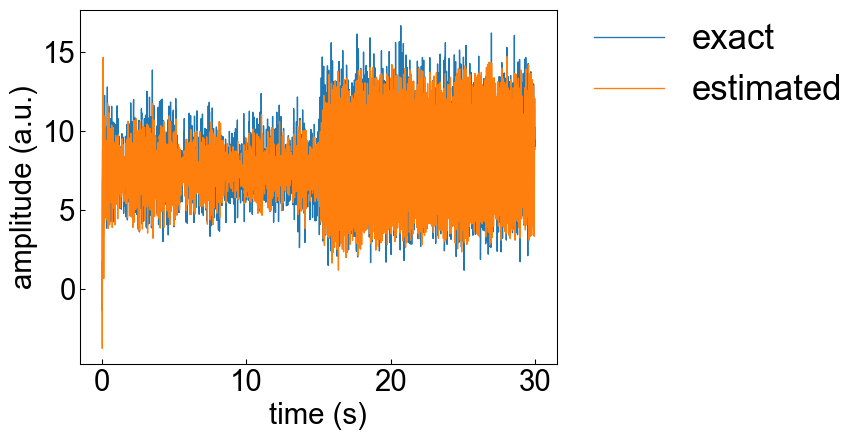

In [10]:
plt.plot(time, eeg, label='exact', zorder=1);
plt.plot(time, eeg_pred[0,:],    label='estimated', zorder=2);
plt.xlabel('time (s)')
plt.ylabel('amplitude (a.u.)')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0, fontsize=26, frameon=False)
plt.show()